# 00 - Mayo2 Data Preparation and Sparse-View CT Degradation

Prepare clean Mayo2 slices and noisy sparse-view sinograms for the reconstruction notebooks.


## Environment, Paths, and Fixed Parameters

Set paths, imports, acquisition geometry, angle counts, and noise level.


In [ ]:
!pip install astra-toolbox

from google.colab import drive

drive.mount("/content/drive")

import json
import shutil
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from tqdm.auto import tqdm

PROJECT_ROOT = Path("/content/drive/MyDrive/LM_INFORMATICA/COMPUTATIONAL_IMAGING")
MAYO_DIR = PROJECT_ROOT / "Mayo2"
TRAIN_DIR = MAYO_DIR / "train"
VAL_DIR = MAYO_DIR / "val"
TEST_DIR = MAYO_DIR / "test"
IPPY_DIR = PROJECT_ROOT / "IPPy"
OUTPUT_DIR = PROJECT_ROOT / "processed2"

sys.path.append(str(PROJECT_ROOT))

from IPPy import operators, utilities
from IPPy.utilities import load_image, normalize

SEED = 42
DETECTOR_SIZE = 512
IMAGE_SIZE = 256
ANGLE_COUNTS = (180, 90, 60, 45)
GEOMETRY = "parallel"
NOISE_LEVEL = 0.005

torch.manual_seed(SEED)
np.random.seed(SEED)
device = utilities.get_device()
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Mayo directory:", MAYO_DIR)
print("IPPy directory:", IPPY_DIR)
print("Output directory:", OUTPUT_DIR)
print("Angle counts:", ANGLE_COUNTS)
print("Noise level:", NOISE_LEVEL)
print("Device used:", device)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project root: /content/drive/MyDrive/LM_INFORMATICA/COMPUTATIONAL_IMAGING
Mayo directory: /content/drive/MyDrive/LM_INFORMATICA/COMPUTATIONAL_IMAGING/Mayo2
IPPy directory: /content/drive/MyDrive/LM_INFORMATICA/COMPUTATIONAL_IMAGING/IPPy
Output directory: /content/drive/MyDrive/LM_INFORMATICA/COMPUTATIONAL_IMAGING/processed512
Angle counts: (180, 90, 60, 45)
Noise level: 0.005


## Dataset Loading and Preprocessing

Load Mayo2 slices, resize them to `256 x 256`, and normalize clean image tensors.


In [ ]:
def collect_png_paths(split_dir: Path) -> list[Path]:
    return sorted(split_dir.glob("*/*.png"))


def ensure_4d_grayscale(image: torch.Tensor) -> torch.Tensor:
    image = torch.as_tensor(image).float()

    if image.ndim == 2:
        image = image.unsqueeze(0).unsqueeze(0)
    elif image.ndim == 3:
        image = image.unsqueeze(0) if image.shape[0] == 1 else image.permute(2, 0, 1).unsqueeze(0)

    return image


def load_and_preprocess_image(image_path: Path) -> torch.Tensor:
    image = load_image(str(image_path))
    image = ensure_4d_grayscale(image)
    image = F.interpolate(
        image,
        size=(IMAGE_SIZE, IMAGE_SIZE),
        mode="bilinear",
        align_corners=False,
    )
    return normalize(image).clamp(0.0, 1.0).to(torch.float32)


def load_clean_batch(paths: list[Path]) -> torch.Tensor:
    return torch.cat([load_and_preprocess_image(path) for path in paths], dim=0)


split_paths = {
    "train": collect_png_paths(TRAIN_DIR),
    "val": collect_png_paths(VAL_DIR),
    "test": collect_png_paths(TEST_DIR),
}

for split_name, paths in split_paths.items():
    print(f"{split_name}: {len(paths)} images")

sample_clean = load_and_preprocess_image(split_paths["train"][0])
print("Sample clean shape:", tuple(sample_clean.shape))
print("Sample clean range:", float(sample_clean.min()), float(sample_clean.max()))

train: 2585 images
val: 721 images
test: 327 images
Sample clean shape: (1, 1, 256, 256)
Sample clean range: 0.0 1.0


## Forward CT Model and Patient-Level Export Functions

Define the CT forward model, add measurement noise, and save one processed `.pt` file per patient.


In [ ]:
projectors = {
    str(n_views): operators.CTProjector(
        img_shape=(IMAGE_SIZE, IMAGE_SIZE),
        angles=np.linspace(0.0, np.pi, n_views),
        det_size=DETECTOR_SIZE,
        geometry=GEOMETRY,
    )
    for n_views in ANGLE_COUNTS
}


@torch.no_grad()
def make_noisy_sinograms(clean_batch: torch.Tensor) -> tuple[dict[str, torch.Tensor], dict[str, float]]:
    sinograms = {}
    relative_noise = {}

    for key, projector in projectors.items():
        noisy_measurements = []
        sample_noise_levels = []

        for image in clean_batch:
            x = image.unsqueeze(0).to(device)
            y = projector(x)
            noise = utilities.gaussian_noise(y, noise_level=NOISE_LEVEL)

            noisy_measurements.append((y + noise).detach().cpu().to(torch.float32))
            sample_noise_levels.append(float(torch.norm(noise) / torch.norm(y)))

        sinograms[key] = torch.cat(noisy_measurements, dim=0)
        relative_noise[key] = float(np.mean(sample_noise_levels))

    return sinograms, relative_noise


def group_paths_by_patient(paths: list[Path]) -> dict[str, list[Path]]:
    patient_paths = {}
    for path in paths:
        patient_id = path.parent.name
        patient_paths.setdefault(patient_id, []).append(path)
    return patient_paths


def save_patient_file(split_name: str, patient_id: str, patient_image_paths: list[Path]) -> dict:
    clean = load_clean_batch(patient_image_paths)
    sinograms, relative_noise = make_noisy_sinograms(clean)

    patient_path = OUTPUT_DIR / split_name / f"{patient_id}.pt"
    patient_path.parent.mkdir(parents=True, exist_ok=True)
    source_paths = [str(path) for path in patient_image_paths]

    payload = {
        "clean": clean.detach().cpu().to(torch.float32),
        "sinograms": sinograms,
        "source_paths": source_paths,
        "metadata": {
            "split": split_name,
            "patient_id": patient_id,
            "num_samples": len(patient_image_paths),
            "image_size": IMAGE_SIZE,
            "angle_counts": list(ANGLE_COUNTS),
            "detector_size": DETECTOR_SIZE,
            "geometry": GEOMETRY,
            "noise_level": NOISE_LEVEL,
            "relative_noise": relative_noise,
        },
    }
    torch.save(payload, patient_path)

    return {
        "path": str(patient_path.relative_to(OUTPUT_DIR)),
        "patient_id": patient_id,
        "num_samples": len(patient_image_paths),
        "source_paths": source_paths,
        "relative_noise": relative_noise,
    }


def save_split_patients(split_name: str, paths: list[Path]) -> list[dict]:
    patient_paths = group_paths_by_patient(paths)
    patient_records = []

    for patient_id, patient_image_paths in tqdm(
        sorted(patient_paths.items()),
        total=len(patient_paths),
        desc=f"{split_name} patients",
    ):
        patient_records.append(save_patient_file(split_name, patient_id, patient_image_paths))

    return patient_records


sample_sinograms, sample_noise = make_noisy_sinograms(sample_clean)
for key, value in sample_sinograms.items():
    print(f"{key} views: {tuple(value.shape)} | relative noise {sample_noise[key]:.6f}")


CUDA not available. CTProjector will use CPU.
Attempting to create ASTRA projector type: 'linear' for 'parallel' geometry...
Successfully created ASTRA projector type: 'linear'
CTProjector initialized. Geometry: parallel. Using GPU: False. FBP Algorithm: FBP
CUDA not available. CTProjector will use CPU.
Attempting to create ASTRA projector type: 'linear' for 'parallel' geometry...
Successfully created ASTRA projector type: 'linear'
CTProjector initialized. Geometry: parallel. Using GPU: False. FBP Algorithm: FBP
CUDA not available. CTProjector will use CPU.
Attempting to create ASTRA projector type: 'linear' for 'parallel' geometry...
Successfully created ASTRA projector type: 'linear'
CTProjector initialized. Geometry: parallel. Using GPU: False. FBP Algorithm: FBP
CUDA not available. CTProjector will use CPU.
Attempting to create ASTRA projector type: 'linear' for 'parallel' geometry...
Successfully created ASTRA projector type: 'linear'
CTProjector initialized. Geometry: parallel. U

## Generate the Processed Dataset

Generate train, validation, and test processed files, then write the manifest.


In [ ]:
for split_name in split_paths:
    split_output_dir = OUTPUT_DIR / split_name
    if split_output_dir.exists():
        shutil.rmtree(split_output_dir)

manifest_path = OUTPUT_DIR / "manifest.json"
manifest_path.unlink(missing_ok=True)

manifest = {
    "project_root": str(PROJECT_ROOT),
    "mayo_dir": str(MAYO_DIR),
    "output_dir": str(OUTPUT_DIR),
    "image_size": IMAGE_SIZE,
    "angle_counts": list(ANGLE_COUNTS),
    "detector_size": DETECTOR_SIZE,
    "geometry": GEOMETRY,
    "noise_level": NOISE_LEVEL,
    "normalization": "IPPy.utilities.normalize after IPPy.utilities.load_image and resize",
    "storage": "one PyTorch .pt file per Mayo2 patient",
    "splits": {},
}

for split_name, paths in split_paths.items():
    patient_records = save_split_patients(split_name, paths)
    manifest["splits"][split_name] = {
        "num_images": len(paths),
        "num_patients": len(patient_records),
        "patients": patient_records,
    }

for split_name, split_info in manifest["splits"].items():
    patient_records = split_info["patients"]
    expected_images = split_info["num_images"]
    expected_patients = split_info["num_patients"]
    saved_files = sorted((OUTPUT_DIR / split_name).glob("*.pt"))
    listed_images = sum(record["num_samples"] for record in patient_records)
    missing_files = [record["path"] for record in patient_records if not (OUTPUT_DIR / record["path"]).exists()]

    if len(saved_files) != expected_patients:
        raise RuntimeError(f"Saved patient-file count mismatch for {split_name}: {len(saved_files)} != {expected_patients}")
    if listed_images != expected_images:
        raise RuntimeError(f"Image count mismatch for {split_name}: {listed_images} != {expected_images}")
    if missing_files:
        raise RuntimeError(f"Missing patient files for {split_name}: {missing_files[:5]}")

manifest_path.write_text(json.dumps(manifest, indent=2), encoding="utf-8")

print("Saved manifest:", manifest_path)


train patients:   0%|          | 0/8 [00:00<?, ?it/s]

val patients:   0%|          | 0/2 [00:00<?, ?it/s]

test patients:   0%|          | 0/1 [00:00<?, ?it/s]

Saved manifest: /content/drive/MyDrive/LM_INFORMATICA/COMPUTATIONAL_IMAGING/processed512/manifest.json


## Visual Sanity Check and Output Summary

Reload one processed patient and plot a clean slice with its noisy sinograms.


Mounted at /content/drive


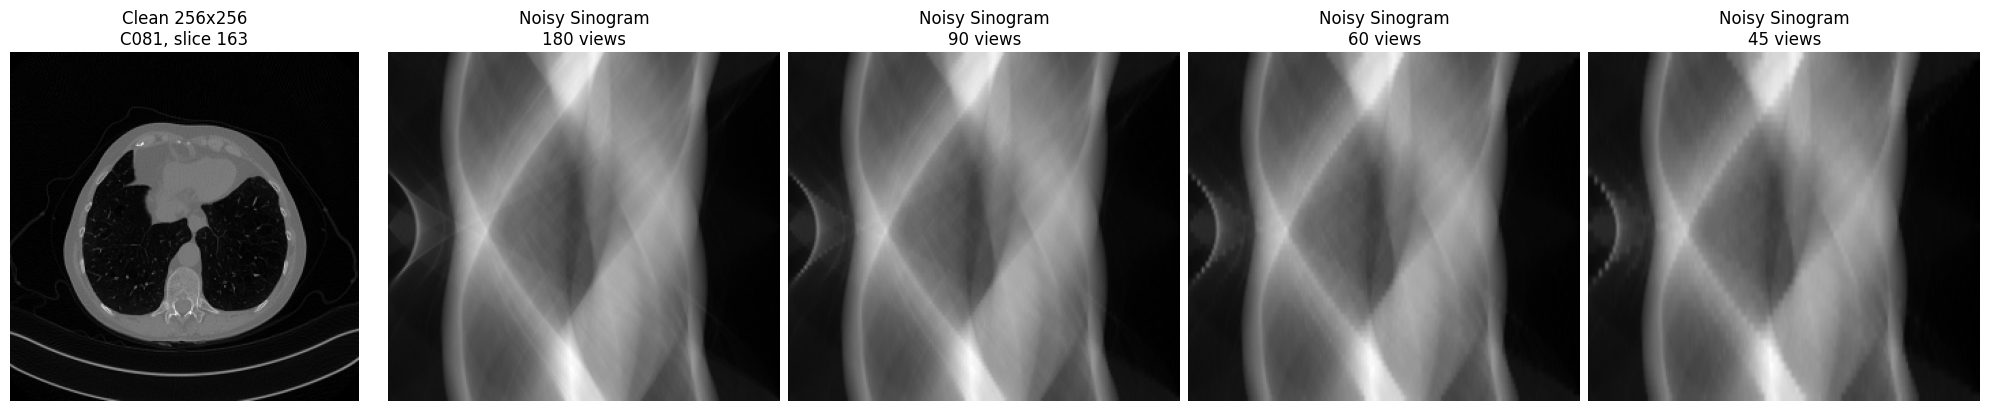

Processed dataset root: /content/drive/MyDrive/LM_INFORMATICA/COMPUTATIONAL_IMAGING/processed2
Manifest: /content/drive/MyDrive/LM_INFORMATICA/COMPUTATIONAL_IMAGING/processed2/manifest.json
Preview: test patient C081 (index 0), slice 163
train: 2585 images, 8 patient files
val: 721 images, 2 patient files
test: 327 images, 1 patient files


In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import torch

if "OUTPUT_DIR" not in globals():
    try:
        from google.colab import drive
        drive.mount("/content/drive")
    except Exception:
        pass

    PROJECT_ROOT = Path("/content/drive/MyDrive/LM_INFORMATICA/COMPUTATIONAL_IMAGING")
    OUTPUT_DIR = PROJECT_ROOT / "processed2"

manifest_path = OUTPUT_DIR / "manifest.json"
if not manifest_path.exists():
    raise FileNotFoundError(f"Processed manifest not found: {manifest_path}")

manifest = json.loads(manifest_path.read_text(encoding="utf-8"))
angle_counts = tuple(manifest["angle_counts"])

preview_split = "test"
preview_patient_records = manifest["splits"][preview_split]["patients"]
preview_patient_idx = len(preview_patient_records) // 2
preview_patient_path = OUTPUT_DIR / preview_patient_records[preview_patient_idx]["path"]
preview_payload = torch.load(preview_patient_path, map_location="cpu")
preview_patient_id = preview_payload["metadata"]["patient_id"]

preview_slice_idx = preview_payload["clean"].shape[0] // 2

clean_preview = preview_payload["clean"][preview_slice_idx, 0].numpy()
sinogram_previews = preview_payload["sinograms"]

fig, axes = plt.subplots(1, 1 + len(angle_counts), figsize=(4 * (1 + len(angle_counts)), 4), constrained_layout=True)
axes[0].imshow(clean_preview, cmap="gray", vmin=0.0, vmax=1.0)
axes[0].set_title(f"Clean 256x256\n{preview_patient_id}, slice {preview_slice_idx}")
axes[0].axis("off")

for ax, n_views in zip(axes[1:], angle_counts):
    key = str(n_views)
    noisy_sino_preview = sinogram_previews[key][preview_slice_idx].squeeze().numpy()
    ax.imshow(noisy_sino_preview, cmap="gray", aspect="auto")
    ax.set_title(f"Noisy Sinogram\n{key} views")
    ax.axis("off")

plt.show()

print("Processed dataset root:", OUTPUT_DIR)
print("Manifest:", OUTPUT_DIR / "manifest.json")
print(f"Preview: {preview_split} patient {preview_patient_id} (index {preview_patient_idx}), slice {preview_slice_idx}")
for split_name, split_info in manifest["splits"].items():
    print(f"{split_name}: {split_info['num_images']} images, {split_info['num_patients']} patient files")


## Loading Contract for Downstream Notebooks

Document the dictionary structure expected by downstream reconstruction notebooks.


In [ ]:
contract_split = "train"
contract_patient_path = OUTPUT_DIR / manifest["splits"][contract_split]["patients"][0]["path"]
contract_payload = torch.load(contract_patient_path, map_location="cpu")

clean = contract_payload["clean"]
sinogram_180 = contract_payload["sinograms"]["180"]
sinogram_90 = contract_payload["sinograms"]["90"]
sinogram_60 = contract_payload["sinograms"]["60"]
sinogram_45 = contract_payload["sinograms"]["45"]
source_paths = contract_payload["source_paths"]
metadata = contract_payload["metadata"]

print("Patient file:", contract_patient_path)
print("clean:", tuple(clean.shape))
print("sinogram_180:", tuple(sinogram_180.shape))
print("sinogram_90:", tuple(sinogram_90.shape))
print("sinogram_60:", tuple(sinogram_60.shape))
print("sinogram_45:", tuple(sinogram_45.shape))
print("patient_id:", metadata["patient_id"])
print("first source path:", source_paths[0])


Patient file: /content/drive/MyDrive/LM_INFORMATICA/COMPUTATIONAL_IMAGING/processed512/train/C002.pt
clean: (278, 1, 256, 256)
sinogram_180: (278, 1, 180, 512)
sinogram_90: (278, 1, 90, 512)
sinogram_60: (278, 1, 60, 512)
sinogram_45: (278, 1, 45, 512)
patient_id: C002
first source path: /content/drive/MyDrive/LM_INFORMATICA/COMPUTATIONAL_IMAGING/Mayo2/train/C002/0.png
